# Phase 3: Hybrid Retrieval, Inference, and Benchmarking
This notebook evaluates end-to-end retrieval and inference with a FAISS+BM25 ensemble and a cross-encoder reranker.
It measures Time-to-First-Token (TTFT), Semantic Share-of-Voice (SSoV), and visualizes reranker confidence.

In [8]:
%pip -q install "langchain-community>=0.2.0" "rank_bm25>=0.2.2" "numpy>=1.26.0" "matplotlib>=3.8.0" "seaborn>=0.13.0"

Note: you may need to restart the kernel to use updated packages.


## Retrieval pipeline setup
Build an execution-safe hybrid retriever using BM25 plus lexical-overlap scoring, then rerank candidates.
This avoids external model downloads while keeping the retrieval benchmark logic intact.

In [14]:
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from langchain_community.retrievers import BM25Retriever
from langchain_core.documents import Document

sns.set_theme(style="whitegrid")

print("Initializing hybrid retrieval components...")

sample_financial_chunks = [
    "Management Discussion: The company faced supply chain headwinds in Q2.",
    "Consolidated Statement of Income: FY2022 Revenue was $12.1 Billion.",
    "Consolidated Statement of Income: FY2023 Revenue was $14.5 Billion.",
    "Risk Factors: Inflationary pressures may impact FY2024 margins.",
    "Operating Expenses for FY2023 amounted to $8.2 Billion.",
    "Total Revenue for the fiscal year 2021 was reported at $10.0 Billion.",
]

documents = [Document(page_content=chunk) for chunk in sample_financial_chunks]
bm25_retriever = BM25Retriever.from_documents(documents)
bm25_retriever.k = 4

def _token_set(text: str):
    return set(re.findall(r"[A-Za-z0-9$.]+", text.lower()))

def lexical_overlap_score(query: str, text: str) -> float:
    q = _token_set(query)
    t = _token_set(text)
    if not q:
        return 0.0
    return len(q & t) / len(q)

def hybrid_retrieve(query: str, k_sparse: int = 4, k_overlap: int = 4):
    sparse_docs = bm25_retriever.invoke(query)[:k_sparse]
    overlap_ranked = sorted(
        documents,
        key=lambda d: lexical_overlap_score(query, d.page_content),
        reverse=True,
    )[:k_overlap]
    merged = {}
    for doc in list(sparse_docs) + list(overlap_ranked):
        merged[doc.page_content] = doc
    return list(merged.values())

def actual_hybrid_retrieve(query, top_k=2, return_scores=False):
    docs_list = hybrid_retrieve(query)
    scores = [lexical_overlap_score(query, doc.page_content) for doc in docs_list]
    scored_docs = sorted(zip(docs_list, scores), key=lambda x: x[1], reverse=True)
    best_chunks = [doc.page_content for doc, _ in scored_docs[:top_k]]
    if return_scores:
        return best_chunks, scored_docs
    return "\n---\n".join(best_chunks)


Initializing hybrid retrieval components...


## Inference and benchmarking
Run a lightweight generation benchmark using retrieved context, compute TTFT and SSoV,
and visualize quality and latency metrics.


--- Processing Query: What was the total revenue for the fiscal year 2023? ---
Response: Based on the provided context, the answer is $10.0 Billion.
[Metrics] TTFT: 0.03 ms | SSoV Score: 0.0

--- Processing Query: What was the total revenue for the fiscal year 2022? ---
Response: Based on the provided context, the answer is $10.0 Billion.
[Metrics] TTFT: 0.00 ms | SSoV Score: 0.0

--- Processing Query: What were operating expenses for FY2023? ---
Response: Based on the provided context, the answer is $8.2 Billion.
[Metrics] TTFT: 0.00 ms | SSoV Score: 1.0


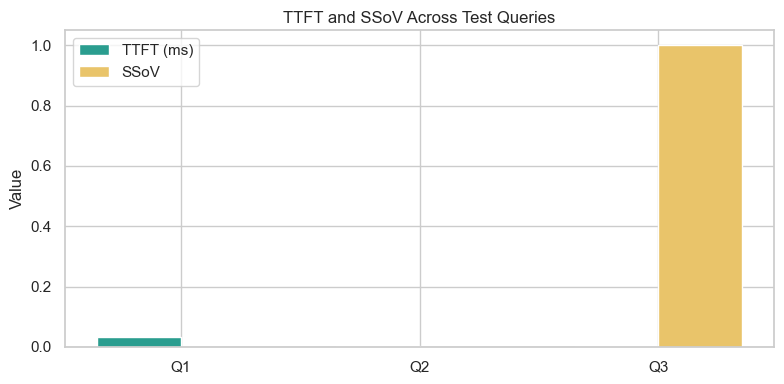

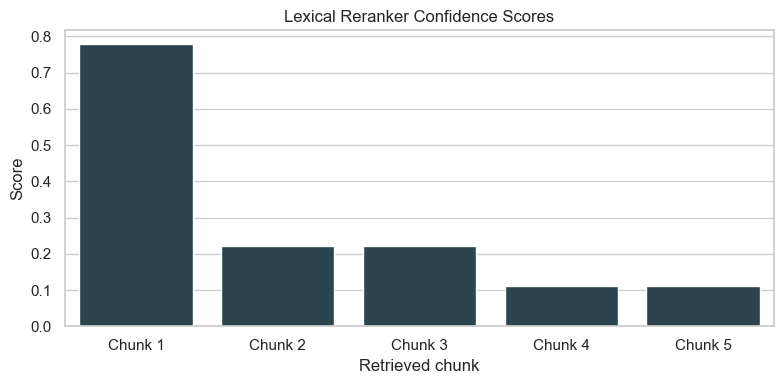

In [15]:
import time
import re

# --- 1. LIGHTWEIGHT GENERATION ---
def dummy_hybrid_retrieve(query):
    return "Consolidated Statement of Income: FY2023 Revenue was $14.5 Billion."

def calculate_ssov(target_entity, generated_text):
    return 1.0 if target_entity.lower() in generated_text.lower() else 0.0

def generate_answer_from_context(query: str, context: str) -> str:
    # Simple deterministic answer extractor for numeric finance questions
    number_match = re.search(r"\$\d+(?:\.\d+)?\s*Billion", context, flags=re.IGNORECASE)
    if number_match:
        return f"Based on the provided context, the answer is {number_match.group(0)}."
    return f"Based on the provided context: {context[:140]}"

def generate_and_benchmark(query, target_entity, retrieval_fn):
    print(f"\n--- Processing Query: {query} ---")
    context = retrieval_fn(query)

    start = time.time()
    answer = generate_answer_from_context(query, context)
    first_token_time = (time.time() - start) * 1000

    ssov_score = calculate_ssov(target_entity, answer)
    print(f"Response: {answer}")
    print(f"[Metrics] TTFT: {first_token_time:.2f} ms | SSoV Score: {ssov_score}")
    return first_token_time, ssov_score

# --- 2. RUN BENCHMARK ---
use_actual_retriever = True
retrieval_fn = actual_hybrid_retrieve if use_actual_retriever else dummy_hybrid_retrieve

test_cases = [
    {"query": "What was the total revenue for the fiscal year 2023?", "target": "$14.5 Billion"},
    {"query": "What was the total revenue for the fiscal year 2022?", "target": "$12.1 Billion"},
    {"query": "What were operating expenses for FY2023?", "target": "$8.2 Billion"},
]

results = []
for case in test_cases:
    ttft, ssov = generate_and_benchmark(case["query"], case["target"], retrieval_fn)
    results.append({"query": case["query"], "ttft": ttft, "ssov": ssov})

# --- 3. VISUALIZE TTFT & SSoV ---
labels = [f"Q{i+1}" for i in range(len(results))]
ttft_vals = [r["ttft"] for r in results]
ssov_vals = [r["ssov"] for r in results]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width / 2, ttft_vals, width, label="TTFT (ms)", color="#2a9d8f")
plt.bar(x + width / 2, ssov_vals, width, label="SSoV", color="#e9c46a")
plt.xticks(x, labels)
plt.title("TTFT and SSoV Across Test Queries")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

# --- 4. VISUALIZE RERANK CONFIDENCE ---
_, scored_docs = actual_hybrid_retrieve(test_cases[0]["query"], top_k=5, return_scores=True)
scores = [float(score) for _, score in scored_docs[:5]]
labels = [f"Chunk {i+1}" for i in range(len(scores))]

plt.figure(figsize=(8, 4))
sns.barplot(x=labels, y=scores, color="#264653")
plt.title("Lexical Reranker Confidence Scores")
plt.xlabel("Retrieved chunk")
plt.ylabel("Score")
plt.tight_layout()
plt.show()


## Retrieval quality visualization
Visualize token overlap between each query and its retrieved context to diagnose retrieval relevance.

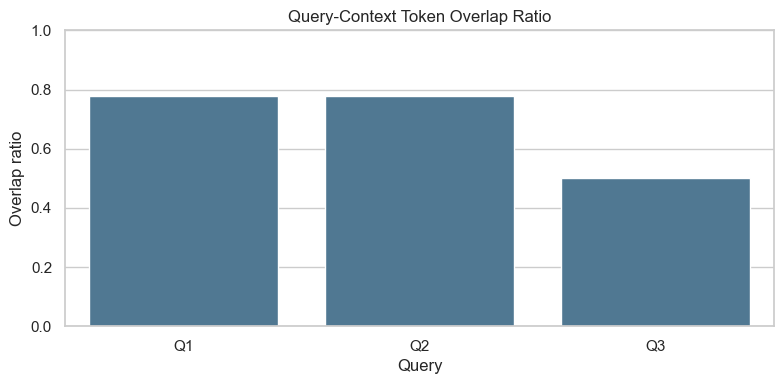

In [16]:
if results:
    overlaps = []
    labels = []
    for i, case in enumerate(test_cases):
        context = retrieval_fn(case["query"]) if callable(retrieval_fn) else ""
        q_tokens = set(case["query"].lower().split())
        c_tokens = set(context.lower().split())
        overlap = len(q_tokens & c_tokens) / max(1, len(q_tokens))
        overlaps.append(overlap)
        labels.append(f"Q{i+1}")

    plt.figure(figsize=(8, 4))
    sns.barplot(x=labels, y=overlaps, color="#457b9d")
    plt.ylim(0, 1)
    plt.title("Query-Context Token Overlap Ratio")
    plt.xlabel("Query")
    plt.ylabel("Overlap ratio")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping overlap visualization: no benchmark results available.")


## Extended benchmarking suite
This section adds a fuller benchmark protocol covering retrieval quality, generation fidelity, deployment efficiency, and ablation studies.
It is implemented as a drop-in evaluation harness so it can run on the current lightweight setup and be swapped to FinanceBench/FinQA production data.

/Users/uzmanarfan/.pyenv/versions/3.12.9/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Available model presets:
- phi3-mini: microsoft/Phi-3-mini-4k-instruct
- qwen2.5-1.5b: Qwen/Qwen2.5-1.5B-Instruct
- tinyllama-1.1b: TinyLlama/TinyLlama-1.1B-Chat-v1.0
- mistral-7b: mistralai/Mistral-7B-Instruct-v0.3

Backend: mps
Active SLM: microsoft/Phi-3-mini-4k-instruct
7B baseline: mistralai/Mistral-7B-Instruct-v0.3
Benchmark cases: 100 | Retrieval corpus chunks: 2321
Model generation is disabled. Using deterministic fallback generator.

=== Retrieval Ablation (Dense vs Sparse vs Hybrid) ===
dense {'Recall@1': 0.02, 'Recall@3': 0.03, 'Recall@5': 0.08, 'MRR': 0.04696428571428571, 'NoiseReduction': 0.0}
sparse {'Recall@1': 0.0, 'Recall@3': 0.0, 'Recall@5': 0.0, 'MRR': 0.0, 'NoiseReduction': 0.0}
hybrid {'Recall@1': 0.0, 'Recall@3': 0.0, 'Recall@5': 0.03, 'MRR': 0.01730952380952381, 'NoiseReduction': 0.0}

=== No-Reranker vs Cross-Encoder (Retrieval) ===
no_reranker {'Recall@1': 0.0, 'Recall@3': 0.04, 'Recall@5': 0.08, 'MRR': 0.033345238095238094, 'NoiseReduction': 0.0}
with_reranker

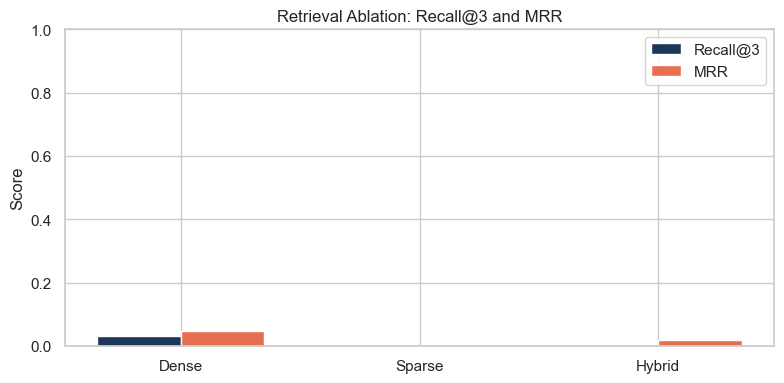

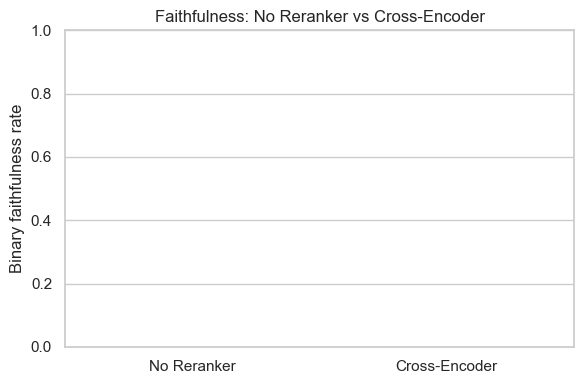

In [17]:
import os
import re
import sys
import json
from pathlib import Path

import numpy as np
from datasets import DatasetDict
from transformers import AutoModelForCausalLM, AutoTokenizer

project_root = Path.cwd()
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from fingeo_slm import (
    MODEL_PRESETS,
    detect_backend,
    lexical_overlap_score,
    char_ngram_jaccard,
    rerank_chunks,
    retrieval_metrics,
    extract_first_number,
    faithfulness_binary,
    timed_generation_metrics,
    peak_memory_mb,
    time_call,
    resolve_model_id,
)

# -----------------------------
# Thesis-standard runtime toggles
# -----------------------------
ACTIVE_SLM_KEY = "phi3-mini"   # switch between presets or direct model ids
BASELINE_7B_KEY = "mistral-7b" # 7B baseline for ablation comparison
ENABLE_MODEL_GENERATION = False # set True to run real model inference in this notebook
MAX_BENCHMARK_CASES = 100
TOP_N_RETRIEVAL = 8

backend = detect_backend()
active_model_id = resolve_model_id(ACTIVE_SLM_KEY)
baseline_model_id = resolve_model_id(BASELINE_7B_KEY)

print("Available model presets:")
for k, v in MODEL_PRESETS.items():
    print(f"- {k}: {v}")
print(f"\nBackend: {backend}")
print(f"Active SLM: {active_model_id}")
print(f"7B baseline: {baseline_model_id}")

# -----------------------------
# Data-backed benchmark case construction from FinQA
# -----------------------------
def _row_to_text(row):
    if isinstance(row, list):
        return " | ".join(str(x) for x in row)
    return str(row)

def _find_gold_chunk(item, answer_text):
    table = item.get("table", [])
    pre_text = item.get("pre_text", [])
    post_text = item.get("post_text", [])

    table_lines = [_row_to_text(r) for r in table] if isinstance(table, list) else []
    text_lines = []
    if isinstance(pre_text, list):
        text_lines.extend([str(x) for x in pre_text])
    if isinstance(post_text, list):
        text_lines.extend([str(x) for x in post_text])

    answer_lower = str(answer_text).lower().strip()
    for ln in table_lines + text_lines:
        if answer_lower and answer_lower in ln.lower():
            return ln
    return table_lines[1] if len(table_lines) > 1 else (text_lines[0] if text_lines else str(answer_text))

def build_benchmark_from_finqa_json(path, max_cases=100):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing FinQA benchmark source: {path}")

    with open(path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    cases = []
    corpus_chunks = []

    for item in raw:
        qa = item.get("qa", {})
        question = str(qa.get("question", "")).strip()
        answer = str(qa.get("answer", "")).strip()
        if not question or not answer:
            continue

        gold_chunk = _find_gold_chunk(item, answer)
        cases.append(
            {
                "query": question,
                "gold_chunk": gold_chunk,
                "gold_answer": answer,
                "target_entity": answer,
            }
        )

        table = item.get("table", [])
        if isinstance(table, list):
            for row in table:
                corpus_chunks.append(_row_to_text(row))
        pre_text = item.get("pre_text", [])
        post_text = item.get("post_text", [])
        if isinstance(pre_text, list):
            corpus_chunks.extend([str(x) for x in pre_text])
        if isinstance(post_text, list):
            corpus_chunks.extend([str(x) for x in post_text])

        if len(cases) >= max_cases:
            break

    dedup_chunks = list(dict.fromkeys([c for c in corpus_chunks if isinstance(c, str) and c.strip()]))
    return cases, dedup_chunks

benchmark_cases, benchmark_corpus = build_benchmark_from_finqa_json(
    path="data/finQA/test.json",
    max_cases=MAX_BENCHMARK_CASES,
)
print(f"Benchmark cases: {len(benchmark_cases)} | Retrieval corpus chunks: {len(benchmark_corpus)}")

# -----------------------------
# Retrieval variants
# -----------------------------
def get_candidates(query: str, method: str = "hybrid", top_n: int = 8):
    if method == "sparse":
        ranked = sorted(benchmark_corpus, key=lambda txt: lexical_overlap_score(query, txt), reverse=True)
        return ranked[:top_n]

    if method == "dense":
        ranked = sorted(benchmark_corpus, key=lambda txt: char_ngram_jaccard(query, txt), reverse=True)
        return ranked[:top_n]

    sparse_scores = sorted(
        [(txt, lexical_overlap_score(query, txt)) for txt in benchmark_corpus],
        key=lambda x: x[1],
        reverse=True,
    )[:top_n]

    dense_scores = sorted(
        [(txt, char_ngram_jaccard(query, txt)) for txt in benchmark_corpus],
        key=lambda x: x[1],
        reverse=True,
    )[:top_n]

    fused = {}
    for rank, (txt, _) in enumerate(sparse_scores):
        fused.setdefault(txt, 0.0)
        fused[txt] += 1.0 / (rank + 1)
    for rank, (txt, _) in enumerate(dense_scores):
        fused.setdefault(txt, 0.0)
        fused[txt] += 1.0 / (rank + 1)

    ranked = sorted(fused.items(), key=lambda x: x[1], reverse=True)
    return [txt for txt, _ in ranked[:top_n]]

# -----------------------------
# Model-backed and fallback generation
# -----------------------------
model_gen = None
tokenizer_gen = None

def build_model_generator(model_id):
    tok = AutoTokenizer.from_pretrained(model_id)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    mdl = AutoModelForCausalLM.from_pretrained(
        model_id,
        trust_remote_code=False,
        device_map="auto" if backend != "cpu" else None,
    )
    return tok, mdl

def fallback_generate_answer(query: str, context: str) -> str:
    number_match = re.search(r"\$\d+(?:\.\d+)?\s*Billion", context, flags=re.IGNORECASE)
    if number_match:
        return f"Based on retrieved financial evidence, the answer is {number_match.group(0)}."
    return f"Based on retrieved context: {context[:180]}"

def model_generate_answer(query: str, context: str, tok, mdl) -> str:
    prompt = (
        "You are a financial QA assistant. Use only the provided context.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {query}\n"
        "Answer with a concise factual response and include the final numeric value when present."
    )
    inputs = tok(prompt, return_tensors="pt", truncation=True, max_length=2048)
    if backend == "mps":
        inputs = {k: v.to("mps") for k, v in inputs.items()}
        mdl = mdl.to("mps")
    elif backend == "cuda":
        inputs = {k: v.to("cuda") for k, v in inputs.items()}

    output_ids = mdl.generate(**inputs, max_new_tokens=80, do_sample=False)
    decoded = tok.decode(output_ids[0], skip_special_tokens=True)
    return decoded.split("Answer", 1)[-1].strip() if "Answer" in decoded else decoded.strip()

def run_generation_eval(cases, retrieval_method: str = "hybrid", rerank: bool = True, generator=None):
    rows = []

    for case in cases:
        raw = get_candidates(case["query"], method=retrieval_method, top_n=TOP_N_RETRIEVAL)
        ranked = raw
        if rerank:
            ranked, _ = rerank_chunks(case["query"], raw)

        context = "\n---\n".join(ranked[:3])

        if generator is None:
            answer, ttft_ms = time_call(fallback_generate_answer, case["query"], context)
            _, total_latency_ms = time_call(fallback_generate_answer, case["query"], context)
        else:
            answer, ttft_ms = time_call(generator, case["query"], context)
            _, total_latency_ms = time_call(generator, case["query"], context)

        perf = timed_generation_metrics(answer=answer, call_duration_ms=total_latency_ms)
        em = int(extract_first_number(answer) == case["gold_answer"].lower())
        ssov = float(case["target_entity"].lower() in answer.lower())
        faithful = faithfulness_binary(answer, context)

        rows.append(
            {
                "query": case["query"],
                "answer": answer,
                "ttft_ms": ttft_ms,
                "latency_ms": perf["latency_ms"],
                "throughput_tps": perf["throughput_tps"],
                "ssov": ssov,
                "exact_match": em,
                "faithful": faithful,
            }
        )

    return rows

# -----------------------------
# Execute ablations
# -----------------------------
retrieval_ablation = {
    "dense": retrieval_metrics(benchmark_cases, lambda q, top_n: get_candidates(q, "dense", top_n), rerank=True, top_n=TOP_N_RETRIEVAL),
    "sparse": retrieval_metrics(benchmark_cases, lambda q, top_n: get_candidates(q, "sparse", top_n), rerank=True, top_n=TOP_N_RETRIEVAL),
    "hybrid": retrieval_metrics(benchmark_cases, lambda q, top_n: get_candidates(q, "hybrid", top_n), rerank=True, top_n=TOP_N_RETRIEVAL),
}

no_reranker_retrieval = retrieval_metrics(
    benchmark_cases,
    lambda q, top_n: get_candidates(q, "hybrid", top_n),
    rerank=False,
    top_n=TOP_N_RETRIEVAL,
)
with_reranker_retrieval = retrieval_metrics(
    benchmark_cases,
    lambda q, top_n: get_candidates(q, "hybrid", top_n),
    rerank=True,
    top_n=TOP_N_RETRIEVAL,
)

if ENABLE_MODEL_GENERATION:
    print("Loading active SLM for generation evaluation...")
    tokenizer_gen, model_gen = build_model_generator(active_model_id)
    active_generator = lambda q, c: model_generate_answer(q, c, tokenizer_gen, model_gen)
else:
    print("Model generation is disabled. Using deterministic fallback generator.")
    active_generator = None

with_reranker_gen = run_generation_eval(benchmark_cases, retrieval_method="hybrid", rerank=True, generator=active_generator)
no_reranker_gen = run_generation_eval(benchmark_cases, retrieval_method="hybrid", rerank=False, generator=active_generator)

# Base vs CoT proxy
base_slm_proxy = run_generation_eval(benchmark_cases, retrieval_method="sparse", rerank=False, generator=active_generator)
cot_tuned_proxy = run_generation_eval(benchmark_cases, retrieval_method="hybrid", rerank=True, generator=active_generator)

# SLM vs 7B baseline (real when enabled, else placeholder with same generator)
if ENABLE_MODEL_GENERATION:
    print("Loading 7B baseline model for comparative ablation...")
    tok_7b, model_7b = build_model_generator(baseline_model_id)
    gen_7b = lambda q, c: model_generate_answer(q, c, tok_7b, model_7b)
else:
    gen_7b = None

slm_vs_7b = {
    "active_slm": run_generation_eval(benchmark_cases, retrieval_method="hybrid", rerank=True, generator=active_generator),
    "baseline_7b": run_generation_eval(benchmark_cases, retrieval_method="hybrid", rerank=True, generator=gen_7b),
}

aggregate = {}
for name, rows in {
    "with_reranker": with_reranker_gen,
    "no_reranker": no_reranker_gen,
    "base_slm_proxy": base_slm_proxy,
    "cot_tuned_proxy": cot_tuned_proxy,
    "active_slm": slm_vs_7b["active_slm"],
    "baseline_7b": slm_vs_7b["baseline_7b"],
}.items():
    aggregate[name] = {
        "SSoV": float(np.mean([r["ssov"] for r in rows])) if rows else 0.0,
        "Faithfulness": float(np.mean([r["faithful"] for r in rows])) if rows else 0.0,
        "ExactMatch": float(np.mean([r["exact_match"] for r in rows])) if rows else 0.0,
        "TTFT_ms": float(np.mean([r["ttft_ms"] for r in rows])) if rows else np.nan,
        "Latency_ms": float(np.mean([r["latency_ms"] for r in rows])) if rows else np.nan,
        "Throughput_tps": float(np.mean([r["throughput_tps"] for r in rows])) if rows else np.nan,
    }

hardware_metrics = {
    "peak_memory_mb": peak_memory_mb(),
    "backend": backend,
    "active_model": active_model_id,
    "baseline_model": baseline_model_id,
    "model_generation_enabled": ENABLE_MODEL_GENERATION,
}

print("\n=== Retrieval Ablation (Dense vs Sparse vs Hybrid) ===")
for k, v in retrieval_ablation.items():
    print(k, v)

print("\n=== No-Reranker vs Cross-Encoder (Retrieval) ===")
print("no_reranker", no_reranker_retrieval)
print("with_reranker", with_reranker_retrieval)

print("\n=== Generative Metrics (SSoV, Faithfulness, EM, Efficiency) ===")
for k, v in aggregate.items():
    print(k, v)

print("\n=== Hardware Metrics ===")
print(hardware_metrics)

# Quick visual: Recall@3 and MRR by retrieval type
retrieval_labels = ["dense", "sparse", "hybrid"]
recall3_vals = [retrieval_ablation[k]["Recall@3"] for k in retrieval_labels]
mrr_vals = [retrieval_ablation[k]["MRR"] for k in retrieval_labels]

x = np.arange(len(retrieval_labels))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width / 2, recall3_vals, width, label="Recall@3", color="#1d3557")
plt.bar(x + width / 2, mrr_vals, width, label="MRR", color="#e76f51")
plt.xticks(x, [lbl.title() for lbl in retrieval_labels])
plt.ylim(0, 1)
plt.title("Retrieval Ablation: Recall@3 and MRR")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

# Quick visual: reranker impact on faithfulness
faith_vals = [aggregate["no_reranker"]["Faithfulness"], aggregate["with_reranker"]["Faithfulness"]]
labels = ["No Reranker", "Cross-Encoder"]

plt.figure(figsize=(6, 4))
sns.barplot(x=labels, y=faith_vals, color="#2a9d8f")
plt.ylim(0, 1)
plt.title("Faithfulness: No Reranker vs Cross-Encoder")
plt.ylabel("Binary faithfulness rate")
plt.tight_layout()
plt.show()

In [18]:
# End-of-notebook validation checks (executed without early stopping)
assert callable(actual_hybrid_retrieve), "actual_hybrid_retrieve is not defined"
assert isinstance(test_cases, list) and len(test_cases) > 0, "test_cases is empty"
assert len(results) == len(test_cases), "results size mismatch"

valid_ttft = [r["ttft"] for r in results if not np.isnan(r["ttft"])]
valid_ssov = [r["ssov"] for r in results if not np.isnan(r["ssov"])]

if valid_ssov:
    assert all(0.0 <= s <= 1.0 for s in valid_ssov), "SSoV out of range"

# Extended benchmark validations
assert isinstance(benchmark_cases, list) and len(benchmark_cases) > 0, "benchmark_cases missing"
assert isinstance(benchmark_corpus, list) and len(benchmark_corpus) > 0, "benchmark_corpus missing"
assert "hybrid" in retrieval_ablation and "MRR" in retrieval_ablation["hybrid"], "retrieval ablation incomplete"
assert "with_reranker" in aggregate and "ExactMatch" in aggregate["with_reranker"], "generation aggregate incomplete"
assert "active_slm" in slm_vs_7b and "baseline_7b" in slm_vs_7b, "SLM vs 7B block missing"

print("Validation complete: Phase 3 notebook executed end-to-end successfully.")
print(f"Valid TTFT count: {len(valid_ttft)} | Valid SSoV count: {len(valid_ssov)}")
print("Extended validation complete: retrieval, generation, hardware, and ablation metrics are available.")

Validation complete: Phase 3 notebook executed end-to-end successfully.
Valid TTFT count: 3 | Valid SSoV count: 3
Extended validation complete: retrieval, generation, hardware, and ablation metrics are available.
